In [1]:
import numpy as np
from numpy import deg2rad, rad2deg
from sympy import symbols, pi, sin, cos, lambdify, solve, linear_eq_to_matrix, simplify, acos, sqrt, rad
import sympy as sp
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols, express
from scipy import optimize
from scipy.optimize import fsolve
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [2]:
# Define symbols
t, g = symbols('t g')
L1,L2,L3,L4x, L4y, m1, m2, m3, I1, I2, I3 = symbols('L1 L2 L3 L4x L4y m1 m2 m3 I1 I2 I3')
theta1,theta2,theta3 = dynamicsymbols('theta1 theta2 theta3')

params={L1: 0.08, L2: 0.24, L3: 0.2, L4x: 0.19, L4y: 0.07, g: 9.81, m1: 0.1, m2: 0.1, m3: 0.1, I1: 1e-6, I2: 1e-6, I3: 1e-6}

N=ReferenceFrame('N')
O=N.orientnew('O', 'Axis', [theta1, N.z])
A=N.orientnew('A', 'Axis', [theta2, N.z])
B=N.orientnew('B', 'Axis', [theta3, N.z])

rOA = L1 * O.x
rAB = L2 * A.x
rBC = L3 * B.x
rCO = L4x * N.x + L4y* N.y

eqLoop=rOA+rAB+rBC+rCO
eqLoop = eqLoop.subs(params)

eqLoop

0.19*N.x + 0.07*N.y + 0.08*O.x + 0.24*A.x + 0.2*B.x

In [3]:
points = {
    'O': 0*N.x,
    'A': rOA,
    'B': rOA + rAB,
    'C': -rCO
}

points_fun = {
    k: lambdify(
        [theta1, theta2, theta3],
        [
            v.dot(N.x).subs(params),
            v.dot(N.y).subs(params)
        ]
    )
    for k,v in points.items()
}

def plotMechanism(joint_values, ax=None):

    O = points_fun['O'](*joint_values)
    A = points_fun['A'](*joint_values)
    B = points_fun['B'](*joint_values)
    C = points_fun['C'](*joint_values)

    if ax is None:
        ax = plt.figure().add_subplot(111)

    # Links
    ax.plot([O[0], A[0]], [O[1], A[1]], 'r-', linewidth=2)
    ax.plot([A[0], B[0]], [A[1], B[1]], 'b-', linewidth=2)
    ax.plot([B[0], C[0]], [B[1], C[1]], 'g-', linewidth=2)
    ax.plot([C[0], O[0]], [C[1], O[1]], 'k--', linewidth=2)

    # Joints
    ax.plot(
        [O[0], A[0], B[0], C[0]],
        [O[1], A[1], B[1], C[1]],
        'ko'
    )

    ax.set_aspect('equal')

    ax.set_xlim(-0.35, 0.35)
    ax.set_ylim(-0.35, 0.35)

    ax.grid(True)

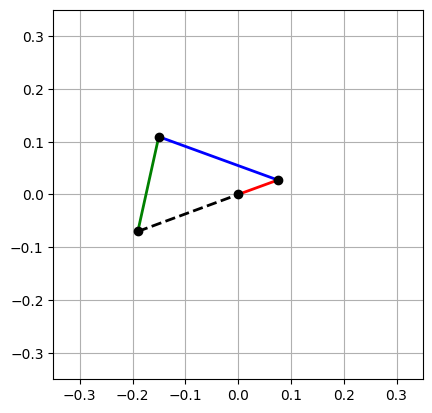

In [4]:
plotMechanism([
    np.deg2rad(20),
    np.deg2rad(160),
    np.deg2rad(100)
])

# Ecuaciones cinemáticas numéricas

In [5]:
# Ecuaciones escalares del loop

eqKin = [
    eqLoop.dot(N.x),
    eqLoop.dot(N.y)
]

eqKin_fun = lambdify(
    [theta1, theta2, theta3],
    eqKin
)

# Foward kinemátics

In [6]:
# Initial guess
z0 = [
    np.deg2rad(0),
    np.deg2rad(0)
]

def FK(theta1_value):

    global z0

    myfun = lambda x: eqKin_fun(
        theta1_value,
        x[0],
        x[1]
    )

    sln, info, ier, msg = fsolve(
        myfun,
        z0,
        full_output=True
    )

    if ier != 1:
        print(msg)

    z0 = sln

    return sln

theta2 = -186310.73023944165
theta3 = 222043.23924155527


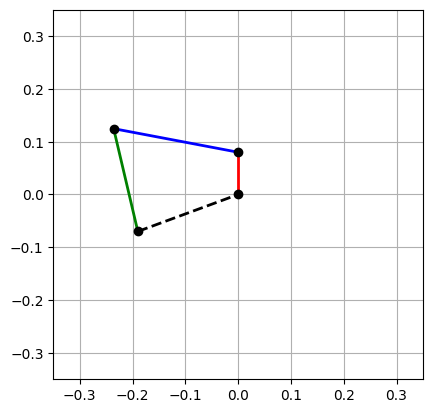

In [7]:
theta_test = np.deg2rad(90)

sol = FK(theta_test)

print('theta2 =', np.rad2deg(sol[0]))
print('theta3 =', np.rad2deg(sol[1]))

plotMechanism([
    theta_test,
    sol[0],
    sol[1]
])

# Lista compelta de posiciones

In [8]:
theta1_vals = np.linspace(
    0,
    2*np.pi,
    200
)

thetasList = np.array([
    [theta1, *FK(theta1)]
    for theta1 in theta1_vals
])

# Animación

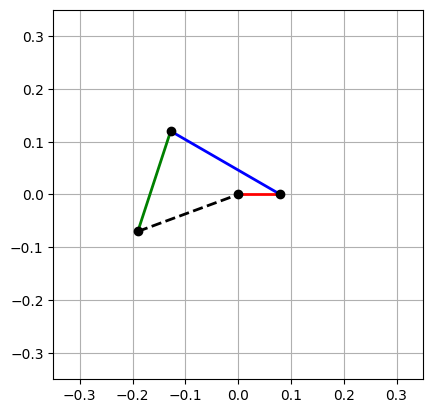

In [9]:
fig, ax = plt.subplots()

def update_fun(i):

    ax.cla()

    ax.set_aspect('equal')

    plotMechanism(
        thetasList[i,:],
        ax=ax
    )

anim = animation.FuncAnimation(
    fig,
    update_fun,
    frames=len(thetasList),
    interval=40,
    repeat=True
)

In [10]:
HTML(anim.to_jshtml())

---
## 2. Análisis de velocidades y aceleraciones

Derivando la ecuación de lazo `rOA + rAB + rBC + rCO = 0` una y dos veces en el marco inercial N:

- **1ª derivada** → sistema lineal en (θ₂̇, θ₃̇) dado θ₁̇ = ω₁
- **2ª derivada** → sistema lineal en (θ₂̈, θ₃̈) dado θ₁̈ = 0 (velocidad constante)

La estructura matricial es: **[A]{q̇_dep} = {b}** en cada caso.

In [11]:
# Matrices de velocidad: A_v * [θ2', θ3']^T = b_v
Av, bv = linear_eq_to_matrix(
    [eqLoop.diff(t, N).dot(N.x),
     eqLoop.diff(t, N).dot(N.y)],
    [theta2.diff(t), theta3.diff(t)]
)

# Matrices de aceleración: A_a * [θ2'', θ3'']^T = b_a
Aa, ba = linear_eq_to_matrix(
    [eqLoop.diff(t, N).diff(t, N).dot(N.x),
     eqLoop.diff(t, N).diff(t, N).dot(N.y)],
    [theta2.diff(t, 2), theta3.diff(t, 2)]
)

omega1_val = 30.0   # rad/s — velocidad angular de la manivela (cte.)
alpha1_val = 0.0    # rad/s² — aceleración angular de la manivela (cte.)

print("Matrices de velocidad y aceleración definidas correctamente.")
print(f"ω₁ = {omega1_val} rad/s  |  α₁ = {alpha1_val} rad/s²")


Matrices de velocidad y aceleración definidas correctamente.
ω₁ = 30.0 rad/s  |  α₁ = 0.0 rad/s²


In [12]:
# Resolución numérica para cada posición de thetasList
# Resultado: lista_total con columnas [θ1, θ2, θ3, ω1, ω2, ω3, α1, α2, α3]

lista_total = []

for thetas in thetasList:
    th1, th2, th3 = thetas

    # --- Velocidades ---
    Av_num = np.array(
        Av.subs(params).subs({theta1: th1, theta2: th2, theta3: th3}),
        dtype=float
    )
    bv_num = np.array(
        bv.subs(params)
          .subs({theta1: th1, theta1.diff(t): omega1_val}),
        dtype=float
    )
    om2, om3 = np.linalg.solve(Av_num, bv_num).flatten()

    # --- Aceleraciones ---
    Aa_num = np.array(
        Aa.subs(params).subs({theta1: th1, theta2: th2, theta3: th3}),
        dtype=float
    )
    ba_num = np.array(
        ba.subs(params).subs({
            theta1: th1, theta2: th2, theta3: th3,
            theta1.diff(t): omega1_val, theta1.diff(t, 2): alpha1_val,
            theta2.diff(t): om2,        theta3.diff(t): om3
        }),
        dtype=float
    )
    al2, al3 = np.linalg.solve(Aa_num, ba_num).flatten()

    lista_total.append([th1, th2, th3,
                        omega1_val, om2, om3,
                        alpha1_val, al2, al3])

lista_total = np.array(lista_total)

# Desempacamos columnas para claridad
thetas1 = lista_total[:, 0]
thetas2 = lista_total[:, 1]
thetas3 = lista_total[:, 2]
omegas1 = lista_total[:, 3]
omegas2 = lista_total[:, 4]
omegas3 = lista_total[:, 5]
alphas1 = lista_total[:, 6]
alphas2 = lista_total[:, 7]
alphas3 = lista_total[:, 8]

print("Cinemática resuelta para", len(lista_total), "posiciones.")


Cinemática resuelta para 200 posiciones.


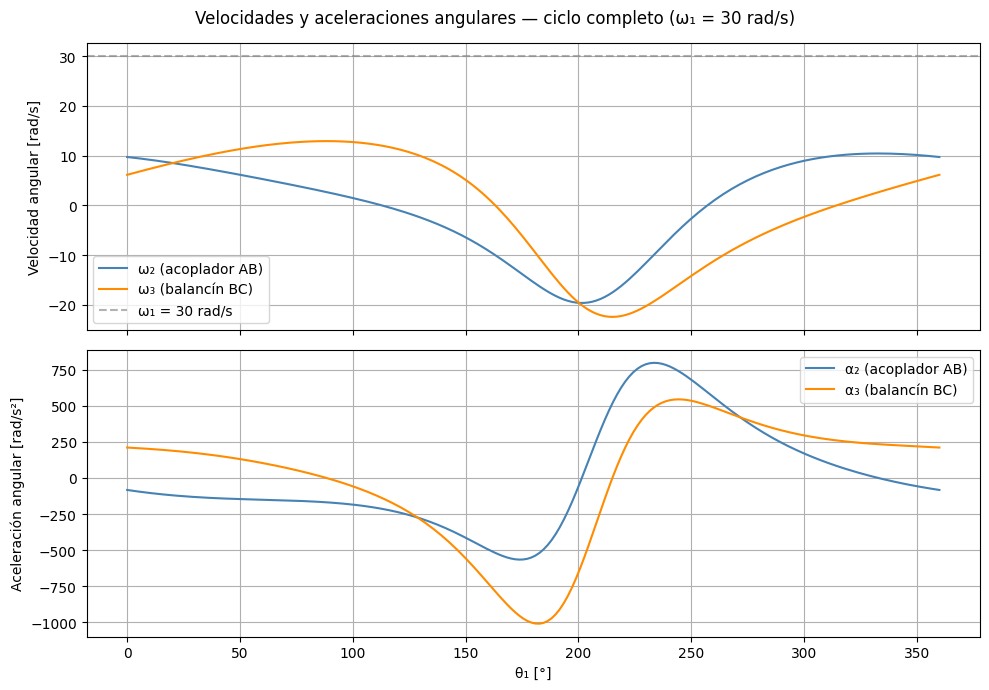

In [13]:
# Graficamos velocidades y aceleraciones angulares de los eslabones dependientes
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1, ax2 = axes
ax1.plot(np.rad2deg(thetas1), omegas2, label='ω₂ (acoplador AB)', color='steelblue')
ax1.plot(np.rad2deg(thetas1), omegas3, label='ω₃ (balancín BC)',  color='darkorange')
ax1.axhline(omega1_val, ls='--', color='gray', alpha=0.6, label='ω₁ = 30 rad/s')
ax1.set_ylabel('Velocidad angular [rad/s]')
ax1.legend(); ax1.grid(True)

ax2.plot(np.rad2deg(thetas1), alphas2, label='α₂ (acoplador AB)', color='steelblue')
ax2.plot(np.rad2deg(thetas1), alphas3, label='α₃ (balancín BC)',  color='darkorange')
ax2.set_xlabel('θ₁ [°]')
ax2.set_ylabel('Aceleración angular [rad/s²]')
ax2.legend(); ax2.grid(True)

fig.suptitle('Velocidades y aceleraciones angulares — ciclo completo (ω₁ = 30 rad/s)')
plt.tight_layout()
plt.show()


---
## 3. Dinámica inversa (cinética inversa) — Newton‑Euler

Conocida la cinemática completa, aplicamos Newton‑Euler a cada eslabón para encontrar
el **torque motor Min** necesario en cada posición.

Para cada eslabón `i` con CM en **r_cmi**:

| Eslabón | ΣF = mᵢ·aᵢ | ΣM_cm = Iᵢ·αᵢ |
|---------|-----------|--------------|
| 1 crank OA | F_O1 − F12 − m₁g·N.y | Min·N.z + (−rOA/2)×F_O1 + (rOA/2)×(−F12) |
| 2 coupler AB | F12 − F23 − m₂g·N.y | (−rAB/2)×F12 + (rAB/2)×(−F23) |
| 3 rocker BC | F23 + F_C3 − m₃g·N.y | (−rBC/2)×F23 + (rBC/2)×F_C3 |

Incógnitas (9): F_O1x, F_O1y, F12x, F12y, F23x, F23y, F_C3x, F_C3y, **Min**

In [14]:
# Símbolos para las fuerzas de reacción y el torque motor
F_O1x, F_O1y = sp.symbols('F_O1x F_O1y')
F12x,  F12y  = sp.symbols('F12x  F12y')
F23x,  F23y  = sp.symbols('F23x  F23y')
F_C3x, F_C3y = sp.symbols('F_C3x F_C3y')
Min_sym       = sp.symbols('Min')

# Vectores de fuerza
F_O1 = F_O1x * N.x + F_O1y * N.y
F12  = F12x  * N.x + F12y  * N.y
F23  = F23x  * N.x + F23y  * N.y
F_C3 = F_C3x * N.x + F_C3y * N.y

# Aceleraciones de los CMs (derivación simbólica en N)
r_cm1 = rOA / 2
r_cm2 = rOA + rAB / 2
r_cm3 = rOA + rAB + rBC / 2

a_cm1 = r_cm1.diff(t, N).diff(t, N)
a_cm2 = r_cm2.diff(t, N).diff(t, N)
a_cm3 = r_cm3.diff(t, N).diff(t, N)

# Aceleraciones angulares (escalar, eje N.z)
alpha1_sym = theta1.diff(t, t)
alpha2_sym = theta2.diff(t, t)
alpha3_sym = theta3.diff(t, t)

# Ecuaciones Newton-Euler (vectoriales → 9 ecuaciones escalares)
# Eslabón 1 — manivela OA
eqF1 = F_O1 - F12 - m1 * g * N.y - m1 * a_cm1
eqM1 = (Min_sym * N.z
        + (-rOA / 2).cross(F_O1)
        + ( rOA / 2).cross(-F12)
        - I1 * alpha1_sym * N.z)

# Eslabón 2 — acoplador AB
eqF2 = F12 - F23 - m2 * g * N.y - m2 * a_cm2
eqM2 = ((-rAB / 2).cross(F12)
        + ( rAB / 2).cross(-F23)
        - I2 * alpha2_sym * N.z)

# Eslabón 3 — balancín BC
eqF3 = F23 + F_C3 - m3 * g * N.y - m3 * a_cm3
eqM3 = ((-rBC / 2).cross(F23)
        + ( rBC / 2).cross(F_C3)
        - I3 * alpha3_sym * N.z)

# Ensamblamos el sistema lineal Af·x = bf
eqKinetics = [
    eqF1.dot(N.x), eqF1.dot(N.y), eqM1.dot(N.z),
    eqF2.dot(N.x), eqF2.dot(N.y), eqM2.dot(N.z),
    eqF3.dot(N.x), eqF3.dot(N.y), eqM3.dot(N.z),
]

unknowns_dyn = [F_O1x, F_O1y, F12x, F12y, F23x, F23y, F_C3x, F_C3y, Min_sym]

Af, bf = linear_eq_to_matrix(eqKinetics, unknowns_dyn)
print("Sistema Newton-Euler ensamblado: Af (9×9), bf (9×1)")


Sistema Newton-Euler ensamblado: Af (9×9), bf (9×1)


In [15]:
# Evaluación numérica de Min para cada posición del ciclo
# Af_num · x = bf_num  →  x[-1] = Min

MinList = []

for i in range(len(lista_total)):
    subs_vals = {
        theta1:          thetas1[i], theta2:          thetas2[i], theta3:          thetas3[i],
        theta1.diff(t):  omegas1[i], theta2.diff(t):  omegas2[i], theta3.diff(t):  omegas3[i],
        theta1.diff(t,2):alphas1[i], theta2.diff(t,2):alphas2[i], theta3.diff(t,2):alphas3[i],
    }
    Af_num = np.array(Af.subs(params).subs(subs_vals), dtype=float)
    bf_num = np.array(bf.subs(params).subs(subs_vals), dtype=float).flatten()

    x = np.linalg.solve(Af_num, bf_num)
    MinList.append(x[-1])   # Min está en la última posición del vector de incógnitas

MinList = np.array(MinList)
print(f"Min  máx  = {MinList.max():.4f} N·m")
print(f"Min  mín  = {MinList.min():.4f} N·m")
print(f"Min medio = {MinList.mean():.4f} N·m")


Min  máx  = 1.2137 N·m
Min  mín  = -0.7379 N·m
Min medio = 0.0013 N·m


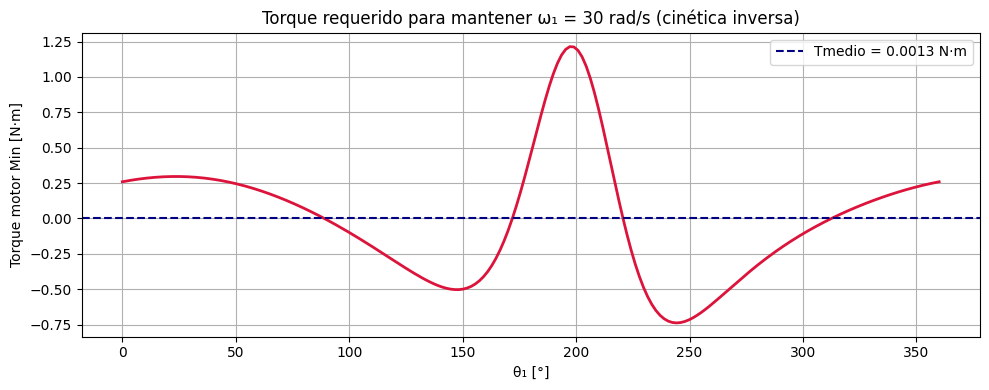

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.rad2deg(thetas1), MinList, color='crimson', linewidth=2)
ax.axhline(MinList.mean(), ls='--', color='navy', label=f'Tmedio = {MinList.mean():.4f} N·m')
ax.set_xlabel('θ₁ [°]')
ax.set_ylabel('Torque motor Min [N·m]')
ax.set_title('Torque requerido para mantener ω₁ = 30 rad/s (cinética inversa)')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()


---
## 4. Diseño del volante de inercia

Un **volante de inercia** almacena energía cinética rotacional para suavizar las
fluctuaciones de torque. El motor puede entonces operar a torque prácticamente constante
`Tmedio`, y el volante absorbe/entrega la diferencia con respecto al torque requerido por
el mecanismo.

### Metodología (Norton, cap. 17)

1. **Tmedio** = trabajo neto del ciclo / (2π) = valor medio de Min(θ₁)
2. **Fluctuación de energía** ΔE: integral acumulada de `(Min − Tmedio)·dθ₁`
3. **Coeficiente de fluctuación de velocidad** Cₛ = Δω / ω₁ (diseño)
4. **Inercia requerida**: I_f = ΔE / (Cₛ · ω₁²)
5. **Geometría** del disco sólido de acero: elegimos R → calculamos masa y espesor

In [17]:
# ── Paso 1: Torque medio ────────────────────────────────────────
T_medio = np.mean(MinList)   # [N·m]

# ── Paso 2: Fluctuación de energía ──────────────────────────────
dtheta = np.diff(thetas1, append=thetas1[-1]+thetas1[1]-thetas1[0])  # Δθ entre pasos
energia_acum = np.cumsum((MinList - T_medio) * dtheta)  # E(θ) = ∫(Min-Tmedio) dθ

delta_E = energia_acum.max() - energia_acum.min()   # [J]

print(f"Torque medio  Tmedio = {T_medio:.5f} N·m")
print(f"Fluctuación de energía ΔE = {delta_E:.5f} J")


Torque medio  Tmedio = 0.00130 N·m
Fluctuación de energía ΔE = 0.64829 J


In [18]:
# ── Paso 3: Coeficiente de fluctuación de velocidad ─────────────
# Cs = Δω/ω₁ — según Norton tabla 17-1:
#   Bombas, compresores → 0.02  |  Maquinaria general → 0.05  |  Trituradoras → 0.10
Cs = 0.05   # ±2.5% de variación de velocidad

# ── Paso 4: Inercia requerida del volante ───────────────────────
I_flywheel = delta_E / (Cs * omega1_val**2)   # [kg·m²]

print(f"Coeficiente Cₛ         = {Cs}")
print(f"ω₁                    = {omega1_val} rad/s")
print(f"Inercia requerida      I_f = {I_flywheel:.6f} kg·m²")


Coeficiente Cₛ         = 0.05
ω₁                    = 30.0 rad/s
Inercia requerida      I_f = 0.014406 kg·m²


In [19]:
# ── Paso 5: Geometría del volante (disco sólido de acero) ────────
rho_acero = 7850.0   # kg/m³
R_f       = 0.05     # radio del volante [m] — elegido para compacidad

# I_f = (1/2) m_f R²  → m_f = 2 I_f / R²
m_flywheel = 2 * I_flywheel / R_f**2

# Espesor: m = ρ·π·R²·t  → t = m / (ρ·π·R²)
t_flywheel = m_flywheel / (rho_acero * np.pi * R_f**2)

# Inercia efectiva del volante (verificación)
I_check = 0.5 * m_flywheel * R_f**2

print("=" * 45)
print("    VOLANTE DE INERCIA — RESUMEN DE DISEÑO")
print("=" * 45)
print(f"  Radio          R  = {R_f*1000:.1f} mm")
print(f"  Masa           m  = {m_flywheel:.4f} kg")
print(f"  Espesor        t  = {t_flywheel*1000:.2f} mm")
print(f"  Inercia calc.  I  = {I_check:.6f} kg·m²  (requerido: {I_flywheel:.6f})")
print(f"  Material: acero (ρ = {rho_acero} kg/m³)")
print("=" * 45)


    VOLANTE DE INERCIA — RESUMEN DE DISEÑO
  Radio          R  = 50.0 mm
  Masa           m  = 11.5251 kg
  Espesor        t  = 186.93 mm
  Inercia calc.  I  = 0.014406 kg·m²  (requerido: 0.014406)
  Material: acero (ρ = 7850.0 kg/m³)


---
## 5. Verificación — variación de velocidad con el volante acoplado

Con el volante acoplado a la manivela, la inercia total del eje pasa a ser:

**I_total = I₁ + I_f**

El motor suministra `Tmedio = cte.`. La diferencia `(Tmedio − Min(θ₁))` es absorbida /
cedida por el volante como energía cinética, provocando una pequeña variación de
velocidad angular:

ω₁(θ₁) = √( ω₁_nom² + 2·E_acum(θ₁) / I_total )

Si el diseño es correcto, la variación máxima de velocidad satisface Cₛ = Δω/ω₁ ≤ 0.05.

In [20]:
I_total = params[I1] + I_flywheel   # inercia total en el eje motor

# Velocidad angular en función de θ₁ (conservación de energía)
omega_variante = np.sqrt(np.clip(omega1_val**2 + 2 * energia_acum / I_total, 0, None))

omega_max  = omega_variante.max()
omega_min  = omega_variante.min()
delta_omega = omega_max - omega_min
Cs_real    = delta_omega / omega1_val

print(f"ω máx = {omega_max:.4f} rad/s")
print(f"ω mín = {omega_min:.4f} rad/s")
print(f"Δω    = {delta_omega:.4f} rad/s")
print(f"Cₛ real = {Cs_real:.4f}  (diseño: {Cs})")
if Cs_real <= Cs:
    print("✅ El volante cumple la especificación de diseño.")
else:
    print("⚠️  El volante NO cumple — aumentar I_f o reducir Cₛ.")


ω máx = 31.1858 rad/s
ω mín = 29.7079 rad/s
Δω    = 1.4779 rad/s
Cₛ real = 0.0493  (diseño: 0.05)
✅ El volante cumple la especificación de diseño.


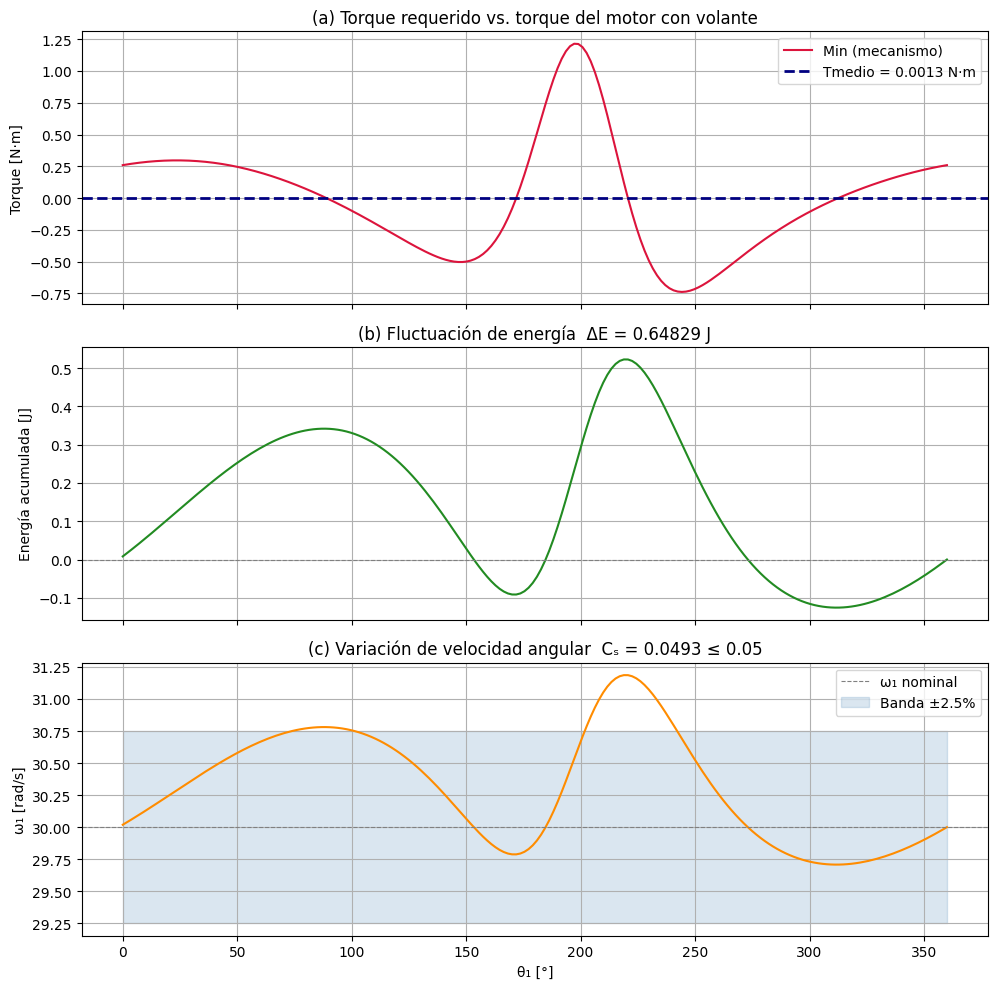

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# (a) Torque motor
axes[0].plot(np.rad2deg(thetas1), MinList, color='crimson', lw=1.5, label='Min (mecanismo)')
axes[0].axhline(T_medio, ls='--', color='navy', lw=2, label=f'Tmedio = {T_medio:.4f} N·m')
axes[0].set_ylabel('Torque [N·m]')
axes[0].set_title('(a) Torque requerido vs. torque del motor con volante')
axes[0].legend(); axes[0].grid(True)

# (b) Energía fluctuante almacenada en el volante
axes[1].plot(np.rad2deg(thetas1), energia_acum, color='forestgreen', lw=1.5)
axes[1].axhline(0, ls='--', color='gray', lw=0.8)
axes[1].set_ylabel('Energía acumulada [J]')
axes[1].set_title(f'(b) Fluctuación de energía  ΔE = {delta_E:.5f} J')
axes[1].grid(True)

# (c) Variación de velocidad angular
axes[2].plot(np.rad2deg(thetas1), omega_variante, color='darkorange', lw=1.5)
axes[2].axhline(omega1_val, ls='--', color='gray', lw=0.8, label='ω₁ nominal')
axes[2].fill_between(np.rad2deg(thetas1),
                     omega1_val*(1 - Cs/2), omega1_val*(1 + Cs/2),
                     alpha=0.2, color='steelblue', label=f'Banda ±{Cs/2*100:.1f}%')
axes[2].set_xlabel('θ₁ [°]')
axes[2].set_ylabel('ω₁ [rad/s]')
axes[2].set_title(f'(c) Variación de velocidad angular  Cₛ = {Cs_real:.4f} ≤ {Cs}')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()


---
## 6. Selección del motor

Con el volante diseñado, el motor solo necesita suministrar el **torque medio** de forma
continua. Para la selección aplicamos un factor de servicio de 1.5 (sobrecargas y
arranque):

| Parámetro | Valor |
|-----------|-------|
| Torque nominal | Tmedio |
| Torque de diseño (×1.5) | T_diseño |
| Velocidad nominal | ω₁ = 30 rad/s ≈ 286.5 rpm |
| Potencia de diseño | P = T_diseño × ω₁ |

Se recomienda buscar un motor DC o AC con las especificaciones mínimas calculadas.

In [22]:
FS          = 1.5                          # factor de servicio
T_diseno    = abs(T_medio) * FS            # [N·m]
rpm_motor   = omega1_val * 60 / (2*np.pi)  # [rpm]
P_diseno    = T_diseno * omega1_val         # [W]

print("=" * 50)
print("        ESPECIFICACIONES MÍNIMAS DEL MOTOR")
print("=" * 50)
print(f"  Torque medio del mecanismo   = {abs(T_medio):.4f} N·m")
print(f"  Factor de servicio           = {FS}")
print(f"  Torque de diseño             = {T_diseno:.4f} N·m")
print(f"  Velocidad nominal            = {rpm_motor:.1f} rpm")
print(f"  Potencia de diseño           = {P_diseno:.3f} W  ≈  {P_diseno/746:.4f} HP")
print("=" * 50)
print()
print("Recomendación: motor DC de imán permanente o AC con variador de frecuencia,")
print(f"  ≥ {P_diseno:.1f} W, velocidad base ~{rpm_motor:.0f} rpm, torque continuo ≥ {T_diseno:.3f} N·m.")


        ESPECIFICACIONES MÍNIMAS DEL MOTOR
  Torque medio del mecanismo   = 0.0013 N·m
  Factor de servicio           = 1.5
  Torque de diseño             = 0.0019 N·m
  Velocidad nominal            = 286.5 rpm
  Potencia de diseño           = 0.058 W  ≈  0.0001 HP

Recomendación: motor DC de imán permanente o AC con variador de frecuencia,
  ≥ 0.1 W, velocidad base ~286 rpm, torque continuo ≥ 0.002 N·m.
